In [ ]:
import pandas as pd
# Replace 'your_file.csv' with your actual file path
df = pd.read_csv('BotnetFull.csv')
# Show the first 5 rows to verify

In [ ]:
print("Shape of the DataFrame:", df.shape)  # (rows, columns)

Shape of the DataFrame: (3458, 456)


In [ ]:
len(df.columns)


456

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8438 - loss: 0.3705 - val_accuracy: 0.9711 - val_loss: 0.1434
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9732 - loss: 0.1117 - val_accuracy: 0.9711 - val_loss: 0.1007
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9822 - loss: 0.0790 - val_accuracy: 0.9783 - val_loss: 0.0807
Epoch 4/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9814 - loss: 0.0683 - val_accuracy: 0.9819 - val_loss: 0.0763
Epoch 5/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9823 - loss: 0.0600 - val_accuracy: 0.9783 - val_loss: 0.0681
Epoch 6/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9861 - loss: 0.0546 - val_accuracy: 0.9747 - val_loss: 0.0652
Epoch 7/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9791 - loss: 0.0573 - val_accuracy: 0.9747 - val_loss: 0.0616
Epoch 8/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9786 - loss: 0.0542 - val_accuracy: 0.9747 - val_loss: 0.0589
E

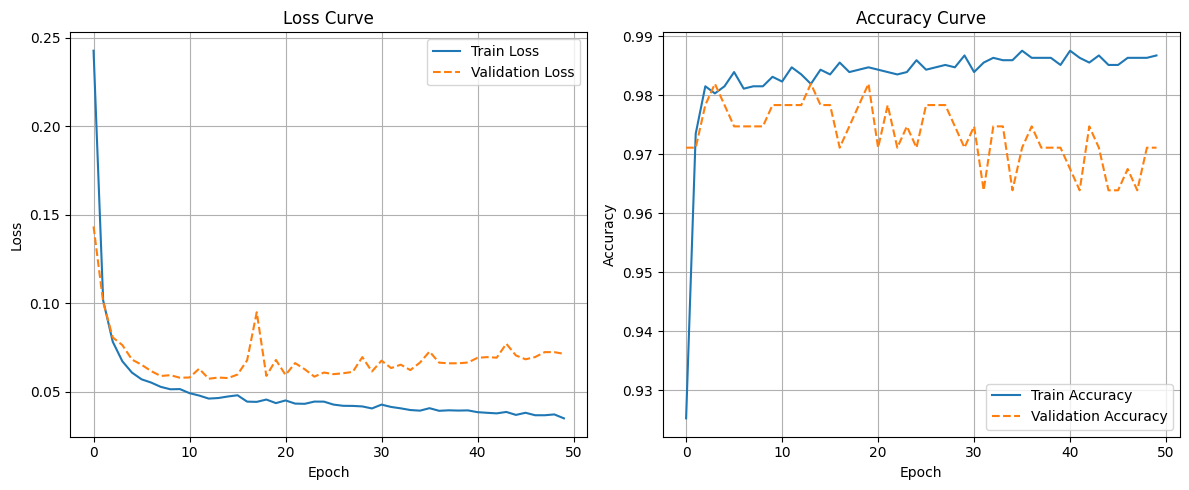

Model saved as botnet_mlp_model_keras.h5


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Step 1: Load and clean the CSV
df = pd.read_csv("BotnetFull.csv")
df.columns = df.columns.str.replace('\n', '', regex=True).str.strip()

# Step 2: Separate features and labels (last column is label)
X = df.iloc[:, :-1].values  # first 455 columns
y = df.iloc[:, -1].values   # last column

# Step 3: Normalize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Step 4: Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
        
# Step 5: Define the MLP model
model = Sequential([
    Dense(454, input_shape=(455,), activation='sigmoid'),  # hidden layer
    Dense(1, activation='sigmoid')                         # output layer
])      

# Step 6: Compile the model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Step 7: Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Step 8: Evaluate the model on test data
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc * 100:.2f}%")

# Step 9: Plot loss and accuracy curves
plt.figure(figsize=(12, 5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss', linestyle='--')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linestyle='--')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Step 10: Save the trained model
model.save("botnet_mlp_model_keras.h5")
print("Model saved as botnet_mlp_model_keras.h5")


In [ ]:
# now trying early stoppning

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8638 - loss: 0.3719 - val_accuracy: 0.9711 - val_loss: 0.1426
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9792 - loss: 0.1054 - val_accuracy: 0.9711 - val_loss: 0.0991
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9840 - loss: 0.0728 - val_accuracy: 0.9819 - val_loss: 0.0813
Epoch 4/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9750 - loss: 0.0753 - val_accuracy: 0.9783 - val_loss: 0.0727
Epoch 5/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9836 - loss: 0.0581 - val_accuracy: 0.9819 - val_loss: 0.0712
Epoch 6/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9813 - loss: 0.0604 - val_accuracy: 0.9783 - val_loss: 0.0743
Epoch 7/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9838 - loss: 0.0476 - val_accuracy: 0.9747 - val_loss: 0.0604
Epoch 8/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9853 - loss: 0.0472 - val_accuracy: 0.9747 - val_loss: 0.0598
Ep

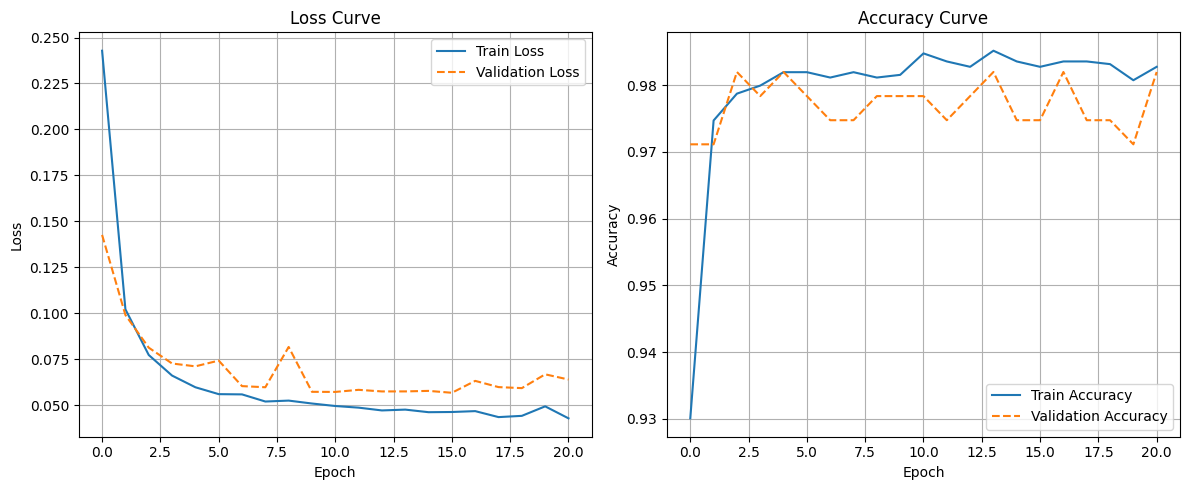

✅ Model saved as 'botnet_mlp_model_keras.h5'


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Step 1: Load and clean the dataset
df = pd.read_csv("BotnetFull.csv")
df.columns = df.columns.str.replace('\n', '', regex=True).str.strip()

# Step 2: Split features and label (last column is label)
X = df.iloc[:, :-1].values  # First 455 columns = features
y = df.iloc[:, -1].values   # Last column = label (0 or 1)

# Step 3: Normalize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Step 4: Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 5: Define the MLP model
model = Sequential([
    Dense(454, input_shape=(455,), activation='sigmoid'),  # Hidden layer
    Dense(1, activation='sigmoid')                         # Output layer
])

# Step 6: Compile the model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Step 7: Add Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Step 8: Train the model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Step 9: Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ Test Accuracy: {test_acc * 100:.2f}%")

# Step 10: Plot loss and accuracy curves
plt.figure(figsize=(12, 5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss', linestyle='--')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linestyle='--')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Step 11: Save the model
model.save("botnet_mlp_model_keras.h5")
print("✅ Model saved as 'botnet_mlp_model_keras.h5'")



In [ ]:
#below i have removed the normalization step and changedd activation function from sigmoid to relu

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8797 - loss: 0.3871 - val_accuracy: 0.9639 - val_loss: 0.1177
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9753 - loss: 0.0884 - val_accuracy: 0.9747 - val_loss: 0.0837
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9814 - loss: 0.0647 - val_accuracy: 0.9783 - val_loss: 0.0777
Epoch 4/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9858 - loss: 0.0534 - val_accuracy: 0.9783 - val_loss: 0.0734
Epoch 5/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9885 - loss: 0.0408 - val_accuracy: 0.9819 - val_loss: 0.0716
Epoch 6/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9845 - loss: 0.0436 - val_accuracy: 0.9783 - val_loss: 0.0695
Epoch 7/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9881 - loss: 0.0350 - val_accuracy: 0.9783 - val_loss: 0.0707
Epoch 8/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9853 - loss: 0.0364 - val_accuracy: 0.9783 - val_loss: 0.0729
Ep

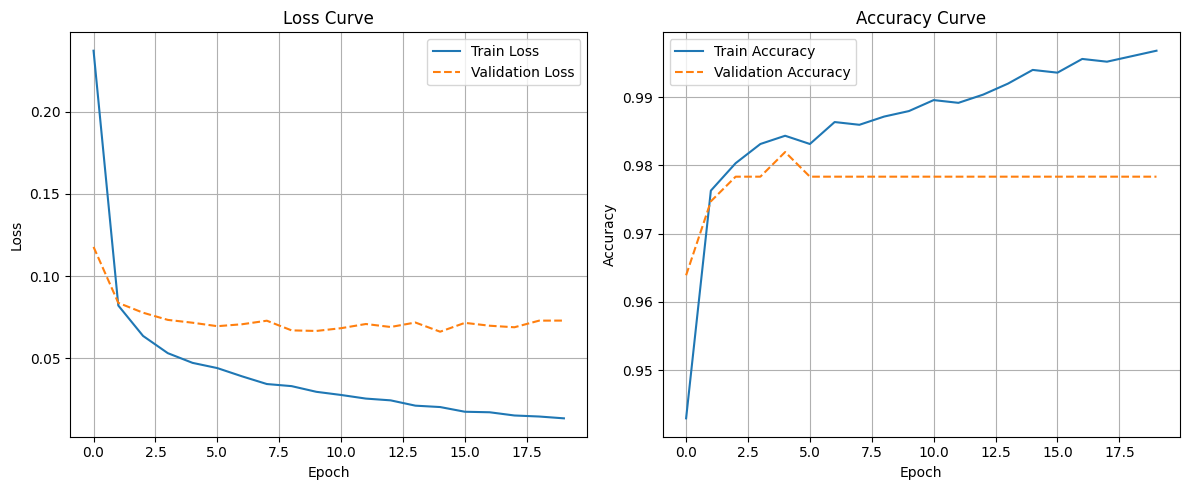

✅ Model saved as 'botnet_mlp_model_keras.h5'


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Step 1: Load and clean the dataset
df = pd.read_csv("BotnetFull.csv")
df.columns = df.columns.str.replace('\n', '', regex=True).str.strip()

# Step 2: Split features and label (last column is label)
X = df.iloc[:, :-1].values  # First 455 columns = features
y = df.iloc[:, -1].values   # Last column = label (0 or 1)

# Step 3: Normalize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Step 4: Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 5: Define the MLP model
model = Sequential([
    Dense(454, input_shape=(455,), activation='relu'),  # Hidden layer
    Dense(1, activation='sigmoid')                         # Output layer
])

# Step 6: Compile the model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Step 7: Add Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Step 8: Train the model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Step 9: Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ Test Accuracy: {test_acc * 100:.2f}%")

# Step 10: Plot loss and accuracy curves
plt.figure(figsize=(12, 5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss', linestyle='--')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linestyle='--')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Step 11: Save the model
model.save("botnet_mlp_model_keras.h5")
print("✅ Model saved as 'botnet_mlp_model_keras.h5'")



In [ ]:
#added some params in early stoppin

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9406 - loss: 0.3578 - val_accuracy: 0.9675 - val_loss: 0.1176
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9777 - loss: 0.0786 - val_accuracy: 0.9783 - val_loss: 0.0831
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9814 - loss: 0.0708 - val_accuracy: 0.9783 - val_loss: 0.0770
Epoch 4/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9841 - loss: 0.0502 - val_accuracy: 0.9783 - val_loss: 0.0742
Epoch 5/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9853 - loss: 0.0426 - val_accuracy: 0.9783 - val_loss: 0.0730
Epoch 6/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9859 - loss: 0.0426 - val_accuracy: 0.9747 - val_loss: 0.0700
Epoch 7/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9842 - loss: 0.0389 - val_accuracy: 0.9783 - val_loss: 0.0773
Epoch 8/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9910 - loss: 0.0318 - val_accuracy: 0.9783 - val_loss: 0.0680
Ep

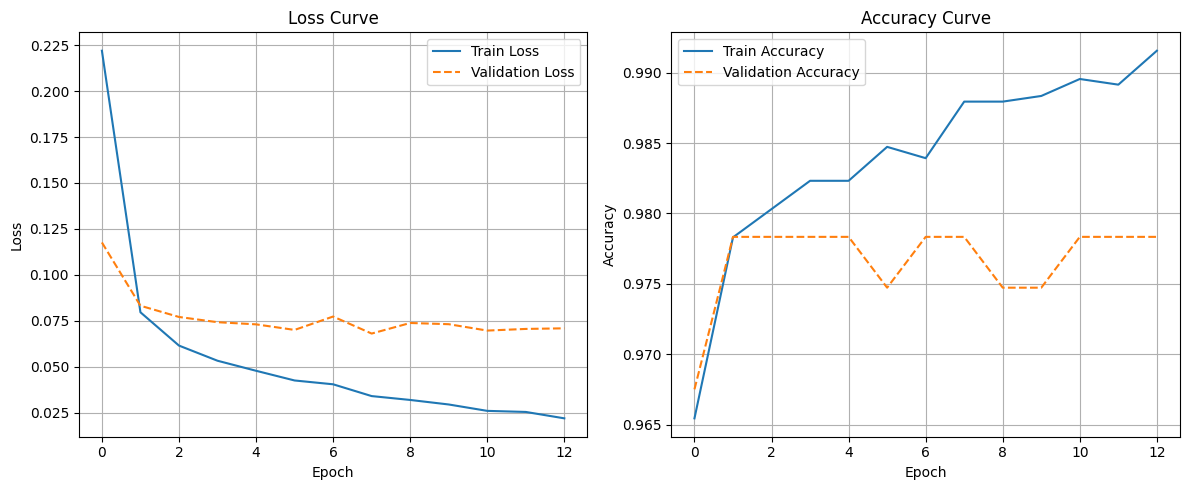

✅ Model saved as 'botnet_mlp_model_keras.h5'


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Step 1: Load and clean the dataset
df = pd.read_csv("BotnetFull.csv")
df.columns = df.columns.str.replace('\n', '', regex=True).str.strip()

# Step 2: Split features and label (last column is label)
X = df.iloc[:, :-1].values  # First 455 columns = features
y = df.iloc[:, -1].values   # Last column = label (0 or 1)

# # Step 3: Normalize features
# scaler = StandardScaler()
# X = scaler.fit_transform(X)

# Step 4: Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 5: Define the MLP model
model = Sequential([
    Dense(454, input_shape=(455,), activation='relu'),  # Hidden layer
    Dense(1, activation='sigmoid')                         # Output layer
])

# Step 6: Compile the model
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Step 7: Add Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    min_delta=0,
    verbose=1,
    mode="auto",
    patience=5,
    baseline=None,
    restore_best_weights=True
)

# Step 8: Train the model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Step 9: Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ Test Accuracy: {test_acc * 100:.2f}%")

# Step 10: Plot loss and accuracy curves
plt.figure(figsize=(12, 5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss', linestyle='--')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linestyle='--')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Step 11: Save the model
model.save("botnet_mlp_model_keras_2.h5")
print("✅ Model saved as 'botnet_mlp_model_keras.h5'")

